In [22]:
import pandas as pd

df = pd.read_csv("Tar_null.csv",encoding='cp949')

In [23]:
df['Target'] =df['업체분류'].map({"정상":0,"부실":1})

In [24]:
df['Target'].value_counts()

Target
0    20279
1     1086
Name: count, dtype: int64

In [25]:
target_cols = ['결산년도',
    'F06','F07','F10','F11','F13','F17','F19','F21','F23',
    'F36','F38','F40','F44','F45','F47',
    'FA01','FA16','FA43',
    'FB10','FB15','FB37','FB42',
    'FC16','FC43','Target'
]

selected_idx = [df.columns.get_loc(col) for col in target_cols if col in df.columns]

data = df.iloc[:, selected_idx]

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21365 entries, 0 to 21364
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   결산년도    21365 non-null  int64  
 1   F06     21365 non-null  float64
 2   F07     21365 non-null  float64
 3   F10     21365 non-null  float64
 4   F11     21365 non-null  float64
 5   F13     21365 non-null  float64
 6   F17     21365 non-null  float64
 7   F19     21365 non-null  float64
 8   F21     21365 non-null  float64
 9   F23     21365 non-null  float64
 10  F36     21365 non-null  float64
 11  F38     21365 non-null  float64
 12  F40     21365 non-null  float64
 13  F44     21365 non-null  float64
 14  F45     21365 non-null  float64
 15  F47     21365 non-null  float64
 16  FA01    21365 non-null  float64
 17  FA16    21365 non-null  float64
 18  FA43    21365 non-null  float64
 19  FB10    21365 non-null  float64
 20  FB15    21365 non-null  float64
 21  FB37    21365 non-null  float64
 22

In [27]:
data['Target'].value_counts()

Target
0    20279
1     1086
Name: count, dtype: int64

In [28]:
train = data[data['결산년도']<=2023].drop(columns=['결산년도'])
test = data[data['결산년도']==2024].drop(columns=['결산년도'])

In [29]:
print(train['Target'].value_counts())
print(test['Target'].value_counts())

Target
0    17974
1     1054
Name: count, dtype: int64
Target
0    2305
1      32
Name: count, dtype: int64


In [30]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19028 entries, 0 to 21362
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F06     19028 non-null  float64
 1   F07     19028 non-null  float64
 2   F10     19028 non-null  float64
 3   F11     19028 non-null  float64
 4   F13     19028 non-null  float64
 5   F17     19028 non-null  float64
 6   F19     19028 non-null  float64
 7   F21     19028 non-null  float64
 8   F23     19028 non-null  float64
 9   F36     19028 non-null  float64
 10  F38     19028 non-null  float64
 11  F40     19028 non-null  float64
 12  F44     19028 non-null  float64
 13  F45     19028 non-null  float64
 14  F47     19028 non-null  float64
 15  FA01    19028 non-null  float64
 16  FA16    19028 non-null  float64
 17  FA43    19028 non-null  float64
 18  FB10    19028 non-null  float64
 19  FB15    19028 non-null  float64
 20  FB37    19028 non-null  float64
 21  FB42    19028 non-null  float64
 22  FC1

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,roc_auc_score
import pandas as pd
import numpy as np

X = train.drop(columns=['Target'])
y = train['Target']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state = 42, stratify=y) # stratify : 클래스 비율을 원본 데이터와 비슷하게 유지해주는 옵션

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)

model = LogisticRegression(class_weight='balanced')
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_train_scaled)
y_prob = model.predict_proba(x_train_scaled)[:,1]

print("Accuracy:", accuracy_score(y_train,y_pred))
print("Recall:", recall_score(y_train,y_pred))
print("Precision:", precision_score(y_train,y_pred))
print("F1_score:", f1_score(y_train,y_pred))
print("roc_auc_score:", roc_auc_score(y_train,y_pred))

Accuracy: 0.7857049008014716
Recall: 0.7544483985765125
Precision: 0.17231102682199945
F1_score: 0.28054697838553155
roc_auc_score: 0.7709928897396089


In [84]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, recall_score,
    precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# 1) X, y 분리
X = train.drop(columns=['Target'])
y = train['Target']

# 2) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3) pipeline: SMOTE -> LogisticRegression
pipe = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(random_state=42, max_iter=5000))
])

# 4) 간단한 하이퍼파라미터 후보
param_grid = [
    {
        "smote__k_neighbors": [5],
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    {
        "smote__k_neighbors": [5],
        "model__solver": ["saga"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    }
]

# 5) CV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    refit=True
)

# 6) 학습
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

# 7) test 평가
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1_score:", f1_score(y_test, y_pred))
print("roc_auc_score:", roc_auc_score(y_test, y_proba))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Params: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear', 'smote__k_neighbors': 5}
Best CV Score: 0.838393970645705
Accuracy: 0.767209668943773
Recall: 0.7345971563981043
Precision: 0.15736040609137056
F1_score: 0.2591973244147157
roc_auc_score: 0.8298426593016894
[[2765  830]
 [  56  155]]
              precision    recall  f1-score   support

           0       0.98      0.77      0.86      3595
           1       0.16      0.73      0.26       211

    accuracy                           0.77      3806
   macro avg       0.57      0.75      0.56      3806
weighted avg       0.93      0.77      0.83      3806



In [85]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, recall_score,
    precision_score, f1_score, roc_auc_score, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# 1) 연도 기준 분리 권장
X_train = train.drop(columns=['Target'])
y_train = train['Target']

X_test = test.drop(columns=['Target'])
y_test = test['Target']

# 2) pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(random_state=42, max_iter=5000))
])

# 3) param grid 확장
param_grid = [
    {
        "smote__k_neighbors": [3, 5, 7],
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__class_weight": [None, "balanced"]
    },
    {
        "smote__k_neighbors": [3, 5, 7],
        "model__solver": ["saga"],
        "model__penalty": ["l1", "l2", "elasticnet"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0.2, 0.5, 0.8],
        "model__class_weight": [None, "balanced"]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="average_precision",   # 또는 roc_auc
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]

# threshold 조정
threshold = 0.35
y_pred = (y_proba >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1_score:", f1_score(y_test, y_pred))
print("roc_auc_score:", roc_auc_score(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 396 candidates, totalling 1980 fits
Best Params: {'model__C': 10, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear', 'smote__k_neighbors': 5}
Best CV Score: 0.2916686478710303
Accuracy: 0.5691056910569106
Recall: 0.75
Precision: 0.02346041055718475
F1_score: 0.04549763033175355
roc_auc_score: 0.7289045553145337
[[1306  999]
 [   8   24]]
              precision    recall  f1-score   support

           0       0.99      0.57      0.72      2305
           1       0.02      0.75      0.05        32

    accuracy                           0.57      2337
   macro avg       0.51      0.66      0.38      2337
weighted avg       0.98      0.57      0.71      2337



# 랜덤포레스트

In [ ]:
import numpy as np
import pandas as pd

from scipy.stats.mstats import winsorize

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


# =========================
# 1. Winsorizer 정의
# =========================
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
        self.columns_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = X.columns
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X.columns = self.columns_

        for col in self.columns_:
            if pd.api.types.is_numeric_dtype(X[col]):
                X[col] = np.array(winsorize(X[col], limits=self.limits))

        return X


# =========================
# 2. 데이터 준비
# =========================
# 예시:
# X = df.drop(columns=["Target", "결산년도"])
# y = df["Target"]

X = train.drop(columns=["Target"])
y = train["Target"]


# =========================
# 3. Train / Test 분리
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# =========================
# 4. 파이프라인
# =========================
pipeline = Pipeline(steps=[
    ("winsor", Winsorizer(limits=(0.01, 0.01))),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])


# =========================
# 5. 하이퍼파라미터 탐색범위
# =========================
param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 3, 5, 7, 10, 15],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", None],
    "model__class_weight": [None, "balanced", "balanced_subsample"]
}


# =========================
# 6. 교차검증 설정
# =========================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# =========================
# 7. RandomizedSearchCV
# =========================
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)


# =========================
# 8. 최적 모델 추출
# =========================
best_model = search.best_estimator_

# test 예측
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


# =========================
# 9. 성능지표 계산
# =========================
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)


# =========================
# 10. 결과 출력
# =========================
print("=" * 50)
print("Best Params:")
print(search.best_params_)

print("\nBest CV Score:")
print(search.best_score_)

print("\n[ Test Set Performance ]")
print(f"Accuracy   : {acc:.6f}")
print(f"Recall     : {rec:.6f}")
print(f"Precision  : {prec:.6f}")
print(f"F1-score   : {f1:.6f}")
print(f"ROC-AUC    : {roc_auc:.6f}")

print("\nConfusion Matrix (교차표):")
print(cm)

print("\nClassification Report:")
print(report)


# =========================
# 11. 변수중요도
# =========================
rf_model = best_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 20 Feature Importances:")
print(feature_importance.head(20))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params:
{'model__n_estimators': 500, 'model__min_samples_split': 20, 'model__min_samples_leaf': 8, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__class_weight': 'balanced'}

Best CV Score:
0.8947902845967493

[ Test Set Performance ]
Accuracy   : 0.885707
Recall     : 0.630332
Precision  : 0.271429
F1-score   : 0.379458
ROC-AUC    : 0.882341

Confusion Matrix (교차표):
[[3238  357]
 [  78  133]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      3595
           1       0.27      0.63      0.38       211

    accuracy                           0.89      3806
   macro avg       0.62      0.77      0.66      3806
weighted avg       0.94      0.89      0.91      3806


Top 20 Feature Importances:
   feature  importance
13     F45    0.110432
14     F47    0.107388
9      F36    0.099570
4      F13    0.081754
3      F11    0.058123
7

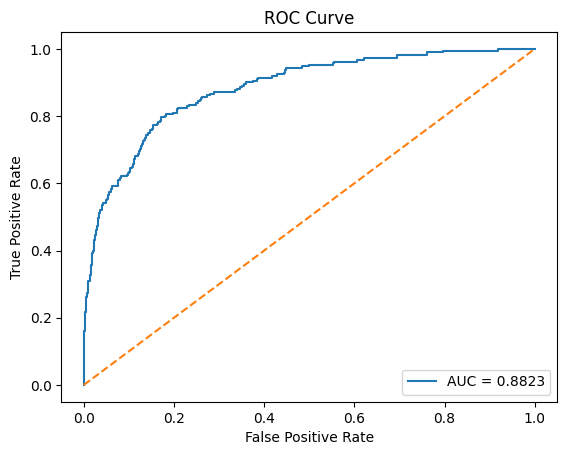

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. 확률값 (이미 있으면 생략 가능)
y_proba = best_model.predict_proba(X_test)[:, 1]

# 2. ROC curve 값 계산
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# 3. AUC 값
auc_score = roc_auc_score(y_test, y_proba)

# 4. 그래프 그리기
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # 랜덤 기준선

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

# LightGBM

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params:
{'model__subsample': 1.0, 'model__reg_lambda': 0.1, 'model__reg_alpha': 1, 'model__num_leaves': 63, 'model__n_estimators': 500, 'model__min_child_samples': 10, 'model__max_depth': -1, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}

Best CV Score:
0.8927305886772888

[ Test Set Performance ]
Accuracy      : 0.917236
Recall        : 0.601896
Precision     : 0.354749
F1-score      : 0.446397
ROC-AUC Score : 0.889336

Confusion Matrix (교차표):
          Pred 0  Pred 1
Actual 0    3364     231
Actual 1      84     127

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3595
           1       0.35      0.60      0.45       211

    accuracy                           0.92      3806
   macro avg       0.67      0.77      0.70      3806
weighted avg       0.94      0.92      0.93      3806



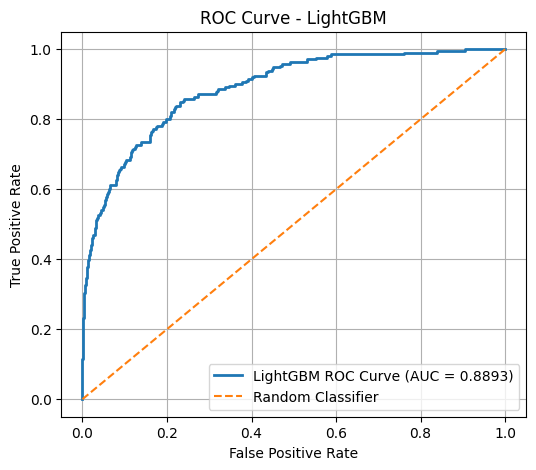


Top 20 Feature Importances:
   feature  importance
21    FB42        2827
9      F36        2363
1      F07        1787
7      F21        1578
16    FA16        1460
11     F40        1459
10     F38        1390
0      F06        1356
22    FC16        1320
8      F23        1297
15    FA01        1295
5      F17        1185
23    FC43        1138
17    FA43        1134
20    FB37        1114
18    FB10        1066
19    FB15        1051
14     F47        1023
12     F44         991
2      F10         894


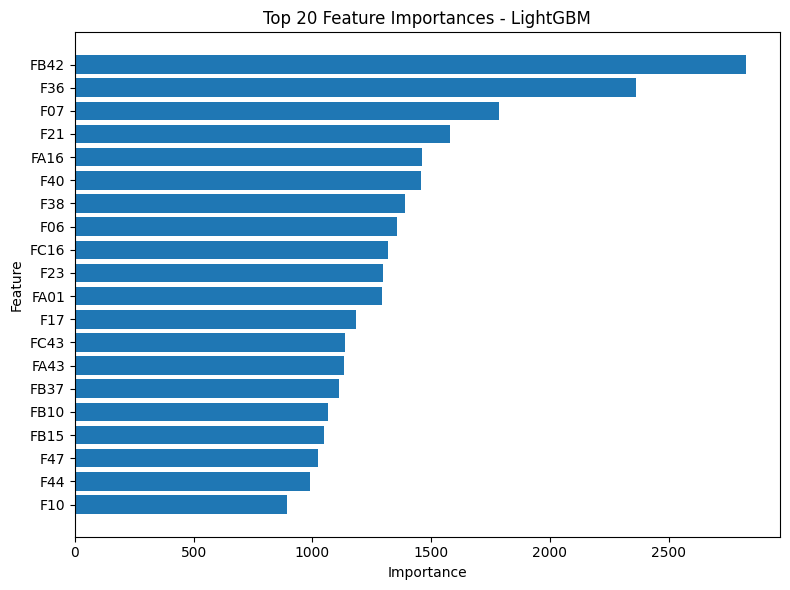

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats.mstats import winsorize

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier


# =========================
# 1. Winsorizer 정의
# =========================
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
        self.columns_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = X.columns
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X.columns = self.columns_

        for col in self.columns_:
            if pd.api.types.is_numeric_dtype(X[col]):
                X[col] = np.array(winsorize(X[col], limits=self.limits))

        return X


# =========================
# 2. 데이터 준비
# =========================
# df는 이미 존재한다고 가정
X = train.drop(columns=["Target"])
y = train["Target"]


# =========================
# 3. Train / Test 분리
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# =========================
# 4. 파이프라인 구성
# =========================
pipeline = Pipeline(steps=[
    ("winsor", Winsorizer(limits=(0.01, 0.01))),
    ("smote", SMOTE(random_state=42)),
    ("model", LGBMClassifier(
        objective="binary",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])


# =========================
# 5. 하이퍼파라미터 탐색 범위
# =========================
param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [-1, 3, 5, 7, 10],
    "model__num_leaves": [15, 31, 63, 127],
    "model__min_child_samples": [10, 20, 30, 50],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [0, 0.01, 0.1, 1]
}


# =========================
# 6. 교차검증 설정
# =========================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# =========================
# 7. RandomizedSearchCV
# =========================
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,              # 시간 여유 있으면 50~100 가능
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)


# =========================
# 8. 최적 모델 추출 및 예측
# =========================
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


# =========================
# 9. 성능지표 계산
# =========================
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred, zero_division=0)
prec = precision_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)

report = classification_report(y_test, y_pred, zero_division=0)


# =========================
# 10. 결과 출력
# =========================
print("=" * 60)
print("Best Params:")
print(search.best_params_)

print("\nBest CV Score:")
print(search.best_score_)

print("\n[ Test Set Performance ]")
print(f"Accuracy      : {acc:.6f}")
print(f"Recall        : {rec:.6f}")
print(f"Precision     : {prec:.6f}")
print(f"F1-score      : {f1:.6f}")
print(f"ROC-AUC Score : {roc_auc:.6f}")

print("\nConfusion Matrix (교차표):")
print(cm_df)

print("\nClassification Report:")
print(report)


# =========================
# 11. ROC Curve 그래프
# =========================
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"LightGBM ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# =========================
# 12. 변수 중요도
# =========================
lgbm_model = best_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 20 Feature Importances:")
print(feature_importance.head(20))


# =========================
# 13. 변수 중요도 그래프
# =========================
top_n = 20
top_features = feature_importance.head(top_n)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Feature Importances - LightGBM")
plt.tight_layout()
plt.show()

# XGBoost

Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\Home\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:57:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params:
{'model__subsample': 0.7, 'model__reg_lambda': 1, 'model__reg_alpha': 0.01, 'model__n_estimators': 200, 'model__max_depth': 10, 'model__learning_rate': 0.01, 'model__gamma': 0, 'model__colsample_bytree': 0.7}

Best CV Score:
0.8934663691201402

[ Test Set Performance ]
Accuracy      : 0.885970
Recall        : 0.682464
Precision     : 0.281800
F1-score      : 0.398892
ROC-AUC Score : 0.884166

Confusion Matrix (교차표):
          Pred 0  Pred 1
Actual 0    3228     367
Actual 1      67     144

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      3595
           1       0.28      0.68      0.40       211

    accuracy                           0.89      3806
   macro avg       0.63      0.79      0.67      3806
weighted avg       0.94      0.89      0.91      3806



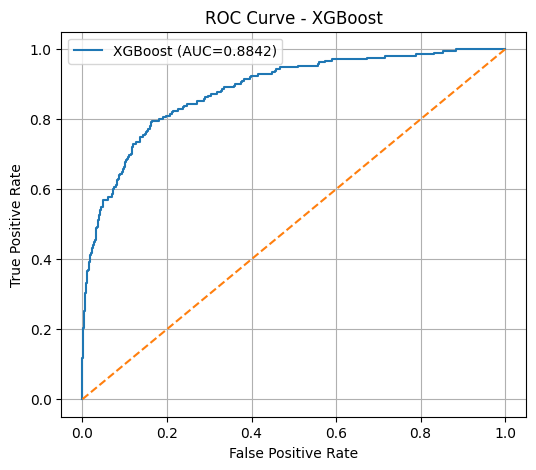


Top 20 Feature Importances:
   feature  importance
14     F47    0.250765
13     F45    0.152856
9      F36    0.072225
7      F21    0.046046
4      F13    0.045926
3      F11    0.036892
22    FC16    0.035740
11     F40    0.029788
16    FA16    0.027806
21    FB42    0.027300
5      F17    0.025282
1      F07    0.023915
19    FB15    0.022903
10     F38    0.021505
0      F06    0.019839
15    FA01    0.019198
8      F23    0.019099
2      F10    0.018990
20    FB37    0.018765
18    FB10    0.017946


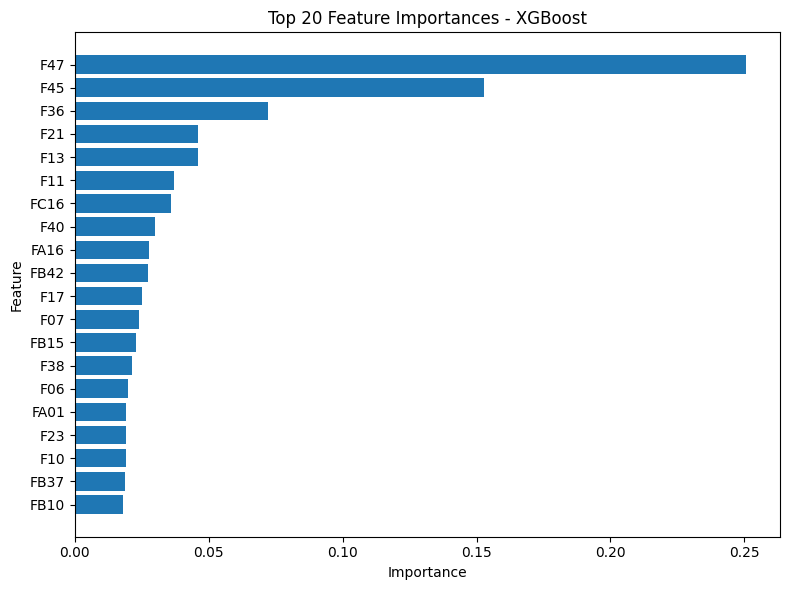

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats.mstats import winsorize

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier


# =========================
# 1. Winsorizer
# =========================
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
        self.columns_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = X.columns
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X.columns = self.columns_

        for col in self.columns_:
            if pd.api.types.is_numeric_dtype(X[col]):
                X[col] = np.array(winsorize(X[col], limits=self.limits))

        return X


# =========================
# 2. 데이터 준비
# =========================
X = train.drop(columns=["Target"])
y = train["Target"]


# =========================
# 3. Train/Test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# =========================
# 4. Pipeline
# =========================
pipeline = Pipeline(steps=[
    ("winsor", Winsorizer(limits=(0.01, 0.01))),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False
    ))
])


# =========================
# 5. Hyperparameter space
# =========================
param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [3, 5, 7, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__gamma": [0, 0.1, 0.3, 1],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [0, 0.01, 0.1, 1]
}


# =========================
# 6. CV
# =========================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# =========================
# 7. RandomizedSearchCV
# =========================
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)


# =========================
# 8. Best model
# =========================
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


# =========================
# 9. Metrics
# =========================
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred, zero_division=0)
prec = precision_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)

report = classification_report(y_test, y_pred, zero_division=0)


# =========================
# 10. Output
# =========================
print("=" * 60)
print("Best Params:")
print(search.best_params_)

print("\nBest CV Score:")
print(search.best_score_)

print("\n[ Test Set Performance ]")
print(f"Accuracy      : {acc:.6f}")
print(f"Recall        : {rec:.6f}")
print(f"Precision     : {prec:.6f}")
print(f"F1-score      : {f1:.6f}")
print(f"ROC-AUC Score : {roc_auc:.6f}")

print("\nConfusion Matrix (교차표):")
print(cm_df)

print("\nClassification Report:")
print(report)


# =========================
# 11. ROC Curve
# =========================
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid()
plt.show()


# =========================
# 12. Feature Importance
# =========================
xgb_model = best_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 20 Feature Importances:")
print(feature_importance.head(20))


# =========================
# 13. Feature Importance Plot
# =========================
top_n = 20
top_features = feature_importance.head(top_n)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

In [ ]:
train.columns


RandomForest 시작
Fitting 5 folds for each of 30 candidates, totalling 150 fits

[RandomForest]
Best Params:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 8, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__class_weight': 'balanced'}

Best CV Score:
0.8954250467308527

[ Test Set Performance ]
Accuracy      : 0.887283
Recall        : 0.625592
Precision     : 0.273859
F1-score      : 0.380952
ROC-AUC Score : 0.881821

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    3245     350
Actual 1      79     132

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      3595
           1       0.27      0.63      0.38       211

    accuracy                           0.89      3806
   macro avg       0.63      0.76      0.66      3806
weighted avg       0.94      0.89      0.91      3806


LightGBM 시작
Fitting 5 folds for each of 30 candidates, totalling 150 fits

[Li

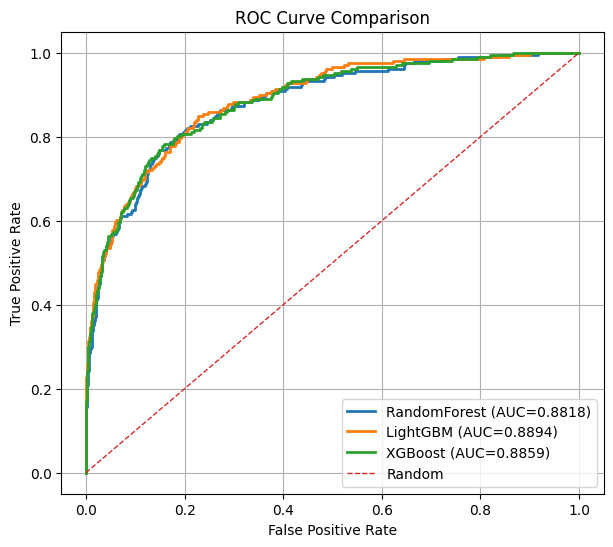


RandomForest Top 20 Feature Importances
   feature  importance
14     F47    0.107374
13     F45    0.105917
9      F36    0.097377
4      F13    0.080197
3      F11    0.058675
7      F21    0.053058
22    FC16    0.052716
2      F10    0.045590
16    FA16    0.041701
21    FB42    0.031622
19    FB15    0.030543
1      F07    0.030176
5      F17    0.030110
12     F44    0.028869
11     F40    0.027997
0      F06    0.025039
10     F38    0.022618
15    FA01    0.020955
20    FB37    0.020608
6      F19    0.018812

LightGBM Top 20 Feature Importances
   feature  importance
21    FB42        3885
9      F36        3194
1      F07        2422
7      F21        2103
11     F40        2004
16    FA16        1989
10     F38        1921
8      F23        1898
0      F06        1881
15    FA01        1847
22    FC16        1843
5      F17        1717
23    FC43        1653
20    FB37        1595
17    FA43        1583
18    FB10        1512
19    FB15        1496
12     F44        1426
14

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats.mstats import winsorize

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# =========================================================
# 1. Winsorizer
# =========================================================
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
        self.columns_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = X.columns
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X.columns = self.columns_
        for col in self.columns_:
            if pd.api.types.is_numeric_dtype(X[col]):
                X[col] = np.array(winsorize(X[col], limits=self.limits))
        return X


# =========================================================
# 2. 데이터 준비
# =========================================================
X = train.drop(columns=["Target"])
y = train["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# =========================================================
# 3. 모델/파라미터 설정
# =========================================================
models = {
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "model__n_estimators": [200, 300, 500, 700],
            "model__max_depth": [None, 5, 10, 15, 20],
            "model__min_samples_split": [2, 5, 10, 20],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__max_features": ["sqrt", "log2", None],
            "model__class_weight": [None, "balanced", "balanced_subsample"]
        }
    },

    "LightGBM": {
        "model": LGBMClassifier(
            objective="binary",
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        "params": {
            "model__n_estimators": [200, 300, 500, 700],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "model__max_depth": [-1, 3, 5, 7, 10],
            "model__num_leaves": [15, 31, 63, 127],
            "model__min_child_samples": [10, 20, 30, 50],
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "model__reg_alpha": [0, 0.01, 0.1, 1],
            "model__reg_lambda": [0, 0.01, 0.1, 1]
        }
    },

    "XGBoost": {
        "model": XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [200, 300, 500, 700],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "model__max_depth": [3, 5, 7, 10],
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "model__gamma": [0, 0.1, 0.3, 1],
            "model__reg_alpha": [0, 0.01, 0.1, 1],
            "model__reg_lambda": [0, 0.01, 0.1, 1]
        }
    }
}


# =========================================================
# 4. 실행
# =========================================================
results = []
best_models = {}
roc_data = {}

for name, info in models.items():
    print("\n" + "=" * 80)
    print(f"{name} 시작")
    print("=" * 80)

    pipeline = Pipeline(steps=[
        ("winsor", Winsorizer(limits=(0.01, 0.01))),
        ("smote", SMOTE(random_state=42)),
        ("model", info["model"])
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=info["params"],
        n_iter=30,              # 시간 여유 있으면 50~100으로 확대
        scoring="roc_auc",
        cv=cv,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, roc_auc)

    print(f"\n[{name}]")
    print("Best Params:")
    print(search.best_params_)
    print("\nBest CV Score:")
    print(search.best_score_)

    print("\n[ Test Set Performance ]")
    print(f"Accuracy      : {acc:.6f}")
    print(f"Recall        : {rec:.6f}")
    print(f"Precision     : {prec:.6f}")
    print(f"F1-score      : {f1:.6f}")
    print(f"ROC-AUC Score : {roc_auc:.6f}")

    print("\nConfusion Matrix:")
    print(pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    ))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    results.append({
        "Model": name,
        "Best_CV_Score": search.best_score_,
        "Accuracy": acc,
        "Recall": rec,
        "Precision": prec,
        "F1_score": f1,
        "ROC_AUC": roc_auc,
        "Best_Params": search.best_params_
    })


# =========================================================
# 5. 결과표 정리
# =========================================================
results_df = pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False)

print("\n" + "=" * 80)
print("최종 모델 비교 결과")
print("=" * 80)
print(results_df[["Model", "Best_CV_Score", "Accuracy", "Recall", "Precision", "F1_score", "ROC_AUC"]])


# =========================================================
# 6. ROC Curve 비교
# =========================================================
plt.figure(figsize=(7, 6))

for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# =========================================================
# 7. 각 모델 변수중요도 보기
# =========================================================
for name, model in best_models.items():
    fitted_model = model.named_steps["model"]

    if hasattr(fitted_model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "feature": X_train.columns,
            "importance": fitted_model.feature_importances_
        }).sort_values(by="importance", ascending=False)

        print("\n" + "=" * 80)
        print(f"{name} Top 20 Feature Importances")
        print("=" * 80)
        print(importance_df.head(20))


RandomForest_SMOTE 시작
Fitting 5 folds for each of 40 candidates, totalling 200 fits

[RandomForest_SMOTE]
Best Params:
{'model__n_estimators': 1000, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': None}

Best CV Score (ROC-AUC):
0.8955535169485035

[ Test Set Performance | threshold = 0.50 ]
Accuracy      : 0.903311
Recall        : 0.606635
Precision     : 0.309927
F1-score      : 0.410256
ROC-AUC Score : 0.882279

Confusion Matrix (0.50):
          Pred 0  Pred 1
Actual 0    3310     285
Actual 1      83     128

Classification Report (0.50):
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      3595
           1       0.31      0.61      0.41       211

    accuracy                           0.90      3806
   macro avg       0.64      0.76      0.68      3806
weighted avg       0.94      0.90      0.92      3806


[ Best Threshold by F1 ]
Best Threshold : 0.65
Accuracy 

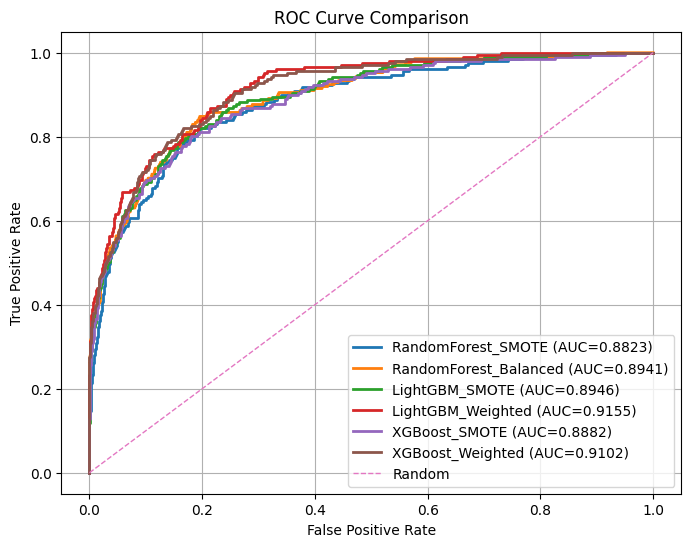

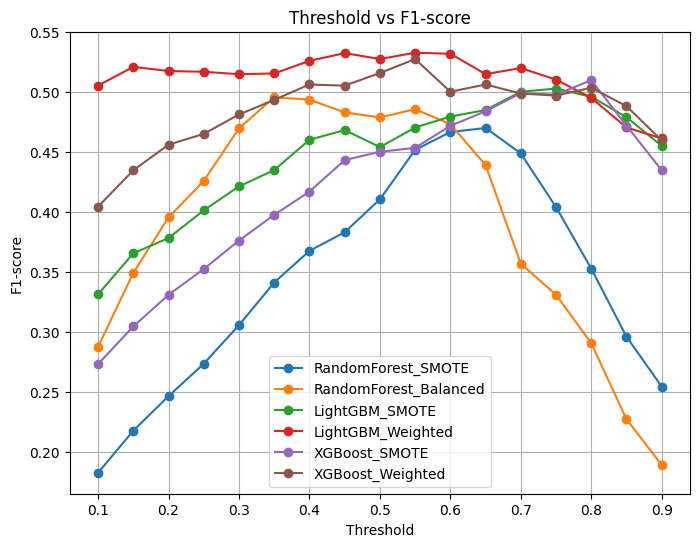


RandomForest_SMOTE Top 20 Feature Importances
   feature  importance
14     F47    0.103331
9      F36    0.098574
13     F45    0.097873
4      F13    0.076599
3      F11    0.055250
7      F21    0.051299
22    FC16    0.050741
2      F10    0.044781
16    FA16    0.040925
21    FB42    0.034207
1      F07    0.031787
5      F17    0.030875
19    FB15    0.030024
12     F44    0.029673
11     F40    0.029655
0      F06    0.026456
10     F38    0.024071
15    FA01    0.023021
20    FB37    0.022636
18    FB10    0.020503

RandomForest_Balanced Top 20 Feature Importances
   feature  importance
13     F45    0.101175
14     F47    0.091832
9      F36    0.089914
4      F13    0.073202
7      F21    0.057191
22    FC16    0.051817
3      F11    0.049629
16    FA16    0.044025
2      F10    0.042224
11     F40    0.033368
12     F44    0.032832
1      F07    0.032309
0      F06    0.031258
5      F17    0.029420
17    FA43    0.028546
19    FB15    0.028331
6      F19    0.025406
21    

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats.mstats import winsorize

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# =========================================================
# 1. Winsorizer
# =========================================================
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
        self.columns_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = X.columns
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X.columns = self.columns_
        for col in self.columns_:
            if pd.api.types.is_numeric_dtype(X[col]):
                X[col] = np.array(winsorize(X[col], limits=self.limits))
        return X


# =========================================================
# 2. Threshold 탐색 함수
# =========================================================
def find_best_threshold(y_true, y_proba, metric="f1", thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    rows = []
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)

        acc = accuracy_score(y_true, y_pred_t)
        rec = recall_score(y_true, y_pred_t, zero_division=0)
        prec = precision_score(y_true, y_pred_t, zero_division=0)
        f1 = f1_score(y_true, y_pred_t, zero_division=0)

        rows.append({
            "threshold": t,
            "accuracy": acc,
            "recall": rec,
            "precision": prec,
            "f1": f1
        })

    thres_df = pd.DataFrame(rows)

    if metric == "f1":
        best_idx = thres_df["f1"].idxmax()
    elif metric == "recall":
        best_idx = thres_df["recall"].idxmax()
    elif metric == "precision":
        best_idx = thres_df["precision"].idxmax()
    else:
        raise ValueError("metric must be one of: 'f1', 'recall', 'precision'")

    return thres_df, thres_df.loc[best_idx]


# =========================================================
# 3. 데이터 준비
# =========================================================
# train 데이터프레임이 이미 존재한다고 가정
X = train.drop(columns=["Target"])
y = train["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# =========================================================
# 4. 모델/파라미터 설정
#    - smote 사용 여부를 모델별로 분리
#    - class_weight/scale_pos_weight 반영
# =========================================================
# 불균형 비율 계산
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count

models = {
    "RandomForest_SMOTE": {
        "use_smote": True,
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "model__n_estimators": [300, 500, 700, 1000],
            "model__max_depth": [None, 8, 12, 16, 20],
            "model__min_samples_split": [2, 5, 10, 20, 30],
            "model__min_samples_leaf": [1, 2, 4, 8, 12],
            "model__max_features": ["sqrt", "log2", None]
        }
    },

    "RandomForest_Balanced": {
        "use_smote": False,
        "model": RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ),
        "params": {
            "model__n_estimators": [300, 500, 700, 1000],
            "model__max_depth": [None, 8, 12, 16, 20],
            "model__min_samples_split": [2, 5, 10, 20, 30],
            "model__min_samples_leaf": [1, 2, 4, 8, 12],
            "model__max_features": ["sqrt", "log2", None]
        }
    },

    "LightGBM_SMOTE": {
        "use_smote": True,
        "model": LGBMClassifier(
            objective="binary",
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        "params": {
            "model__n_estimators": [300, 500, 700, 1000],
            "model__learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05],
            "model__max_depth": [-1, 4, 6, 8, 10],
            "model__num_leaves": [15, 31, 63, 127, 255],
            "model__min_child_samples": [5, 10, 20, 30, 50],
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "model__reg_alpha": [0, 0.01, 0.1, 1, 5],
            "model__reg_lambda": [0, 0.01, 0.1, 1, 5]
        }
    },

    "LightGBM_Weighted": {
        "use_smote": False,
        "model": LGBMClassifier(
            objective="binary",
            random_state=42,
            n_jobs=-1,
            verbose=-1,
            class_weight="balanced"
        ),
        "params": {
            "model__n_estimators": [300, 500, 700, 1000],
            "model__learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05],
            "model__max_depth": [-1, 4, 6, 8, 10],
            "model__num_leaves": [15, 31, 63, 127, 255],
            "model__min_child_samples": [5, 10, 20, 30, 50],
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "model__reg_alpha": [0, 0.01, 0.1, 1, 5],
            "model__reg_lambda": [0, 0.01, 0.1, 1, 5]
        }
    },

    "XGBoost_SMOTE": {
        "use_smote": True,
        "model": XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [300, 500, 700, 1000],
            "model__learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05],
            "model__max_depth": [3, 4, 5, 6, 8],
            "model__min_child_weight": [1, 3, 5, 7],
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "model__gamma": [0, 0.1, 0.3, 1],
            "model__reg_alpha": [0, 0.01, 0.1, 1, 5],
            "model__reg_lambda": [0.01, 0.1, 1, 5]
        }
    },

    "XGBoost_Weighted": {
        "use_smote": False,
        "model": XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight_value
        ),
        "params": {
            "model__n_estimators": [300, 500, 700, 1000],
            "model__learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05],
            "model__max_depth": [3, 4, 5, 6, 8],
            "model__min_child_weight": [1, 3, 5, 7],
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "model__gamma": [0, 0.1, 0.3, 1],
            "model__reg_alpha": [0, 0.01, 0.1, 1, 5],
            "model__reg_lambda": [0.01, 0.1, 1, 5]
        }
    }
}


# =========================================================
# 5. 실행
#    - ROC-AUC 기준으로 튜닝
#    - threshold=0.5 결과 + best threshold 결과 둘 다 저장
# =========================================================
results = []
best_models = {}
roc_data = {}
threshold_tables = {}

for name, info in models.items():
    print("\n" + "=" * 90)
    print(f"{name} 시작")
    print("=" * 90)

    steps = [("winsor", Winsorizer(limits=(0.01, 0.01)))]

    if info["use_smote"]:
        steps.append(("smote", SMOTE(random_state=42)))

    steps.append(("model", clone(info["model"])))
    pipeline = Pipeline(steps=steps)

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=info["params"],
        n_iter=40,                # 시간 여유 있으면 60~100
        scoring="roc_auc",
        cv=cv,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_models[name] = best_model

    # ---------------------------
    # 기본 threshold = 0.5
    # ---------------------------
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred_05 = (y_proba >= 0.5).astype(int)

    acc_05 = accuracy_score(y_test, y_pred_05)
    rec_05 = recall_score(y_test, y_pred_05, zero_division=0)
    prec_05 = precision_score(y_test, y_pred_05, zero_division=0)
    f1_05 = f1_score(y_test, y_pred_05, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)

    cm_05 = confusion_matrix(y_test, y_pred_05)

    # ---------------------------
    # Threshold tuning (F1 최대)
    # ---------------------------
    thres_df, best_thres_row = find_best_threshold(
        y_true=y_test,
        y_proba=y_proba,
        metric="f1",
        thresholds=np.arange(0.10, 0.91, 0.05)
    )
    threshold_tables[name] = thres_df

    best_threshold = best_thres_row["threshold"]
    y_pred_best = (y_proba >= best_threshold).astype(int)

    acc_best = accuracy_score(y_test, y_pred_best)
    rec_best = recall_score(y_test, y_pred_best, zero_division=0)
    prec_best = precision_score(y_test, y_pred_best, zero_division=0)
    f1_best = f1_score(y_test, y_pred_best, zero_division=0)
    cm_best = confusion_matrix(y_test, y_pred_best)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, roc_auc)

    print(f"\n[{name}]")
    print("Best Params:")
    print(search.best_params_)
    print("\nBest CV Score (ROC-AUC):")
    print(search.best_score_)

    print("\n[ Test Set Performance | threshold = 0.50 ]")
    print(f"Accuracy      : {acc_05:.6f}")
    print(f"Recall        : {rec_05:.6f}")
    print(f"Precision     : {prec_05:.6f}")
    print(f"F1-score      : {f1_05:.6f}")
    print(f"ROC-AUC Score : {roc_auc:.6f}")

    print("\nConfusion Matrix (0.50):")
    print(pd.DataFrame(
        cm_05,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    ))

    print("\nClassification Report (0.50):")
    print(classification_report(y_test, y_pred_05, zero_division=0))

    print("\n[ Best Threshold by F1 ]")
    print(f"Best Threshold : {best_threshold:.2f}")
    print(f"Accuracy       : {acc_best:.6f}")
    print(f"Recall         : {rec_best:.6f}")
    print(f"Precision      : {prec_best:.6f}")
    print(f"F1-score       : {f1_best:.6f}")

    print("\nConfusion Matrix (Best Threshold):")
    print(pd.DataFrame(
        cm_best,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    ))

    results.append({
        "Model": name,
        "SMOTE": info["use_smote"],
        "Best_CV_ROC_AUC": search.best_score_,
        "ROC_AUC": roc_auc,

        "Acc_0.50": acc_05,
        "Recall_0.50": rec_05,
        "Precision_0.50": prec_05,
        "F1_0.50": f1_05,

        "Best_Threshold": best_threshold,
        "Acc_BestThres": acc_best,
        "Recall_BestThres": rec_best,
        "Precision_BestThres": prec_best,
        "F1_BestThres": f1_best,

        "Best_Params": search.best_params_
    })


# =========================================================
# 6. 결과표 정리
# =========================================================
results_df = pd.DataFrame(results).sort_values(by="F1_BestThres", ascending=False)

print("\n" + "=" * 90)
print("최종 모델 비교 결과")
print("=" * 90)
print(results_df[[
    "Model", "SMOTE", "Best_CV_ROC_AUC", "ROC_AUC",
    "Recall_0.50", "Precision_0.50", "F1_0.50",
    "Best_Threshold", "Recall_BestThres", "Precision_BestThres", "F1_BestThres"
]])


# =========================================================
# 7. ROC Curve 비교
# =========================================================
plt.figure(figsize=(8, 6))

for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# =========================================================
# 8. Threshold-F1 시각화
# =========================================================
plt.figure(figsize=(8, 6))
for name, thres_df in threshold_tables.items():
    plt.plot(thres_df["threshold"], thres_df["f1"], marker="o", label=name)

plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Threshold vs F1-score")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# 9. 각 모델 변수중요도 보기
# =========================================================
for name, model in best_models.items():
    fitted_model = model.named_steps["model"]

    if hasattr(fitted_model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "feature": X_train.columns,
            "importance": fitted_model.feature_importances_
        }).sort_values(by="importance", ascending=False)

        print("\n" + "=" * 90)
        print(f"{name} Top 20 Feature Importances")
        print("=" * 90)
        print(importance_df.head(20))


# =========================================================
# 10. 최종 추천 모델 확인
# =========================================================
best_final_model_name = results_df.iloc[0]["Model"]
print("\n" + "=" * 90)
print(f"최종 추천 모델: {best_final_model_name}")
print("=" * 90)
print(results_df.iloc[0])

scale_pos_weight: 17.066765578635014

LightGBM_Weighted | Stage 1 broad search
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Stage 1 Best Params:
{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.001, 'num_leaves': 63, 'n_estimators': 900, 'min_split_gain': 0, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 0.6}
Stage 1 Best CV avg_precision: 0.5714666395030396

LightGBM_Weighted | Stage 2 fine search
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Stage 2 Best Params:
{'subsample': 0.7999999999999999, 'reg_lambda': 0.0, 'reg_alpha': 0.0, 'num_leaves': 94, 'n_estimators': 700, 'min_split_gain': 0.0, 'min_child_samples': 15, 'max_depth': -1, 'learning_rate': 0.045, 'colsample_bytree': 0.5499999999999999}
Stage 2 Best CV avg_precision: 0.5756787210452726

----------------------------------------------------------------------------------------------------
[LightGBM_Weighted] FINAL
--------------------------------------

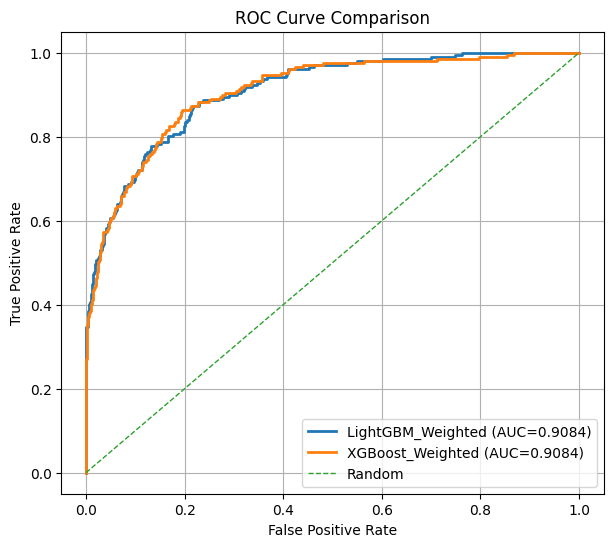

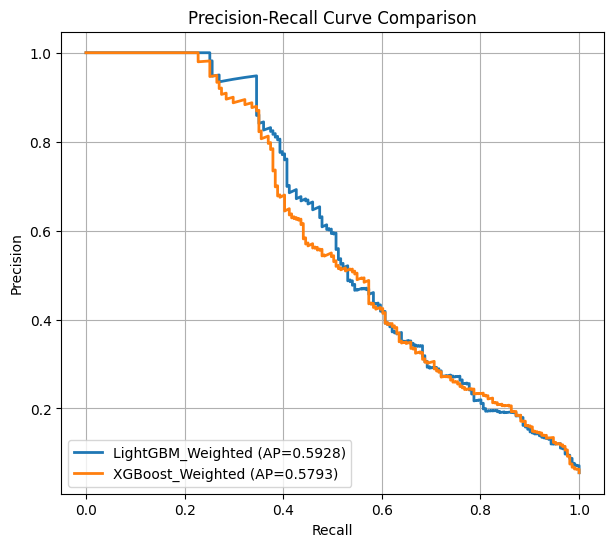

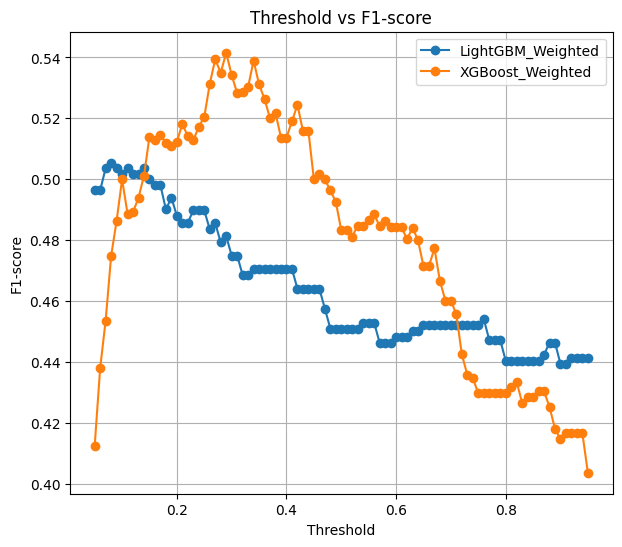


LightGBM_Weighted TOP 20 FEATURE IMPORTANCE
   feature  importance
7      F21        3527
1      F07        3299
21    FB42        3239
9      F36        3180
11     F40        3145
8      F23        3033
0      F06        2783
15    FA01        2748
22    FC16        2735
17    FA43        2722
10     F38        2716
16    FA16        2674
14     F47        2667
5      F17        2629
20    FB37        2585
18    FB10        2557
2      F10        2532
19    FB15        2511
13     F45        2461
23    FC43        2431

XGBoost_Weighted TOP 20 FEATURE IMPORTANCE
   feature  importance
13     F45    0.149617
14     F47    0.109285
9      F36    0.071688
16    FA16    0.045164
4      F13    0.041868
7      F21    0.040671
11     F40    0.036294
22    FC16    0.035484
0      F06    0.033809
21    FB42    0.033048
1      F07    0.032761
17    FA43    0.031874
19    FB15    0.030524
12     F44    0.030024
5      F17    0.029296
3      F11    0.029014
23    FC43    0.028989
10     F38    

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats.mstats import winsorize

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


# =========================================================
# 1. Winsorizer
# =========================================================
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
        self.columns_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = X.columns
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X.columns = self.columns_
        for col in self.columns_:
            if pd.api.types.is_numeric_dtype(X[col]):
                X[col] = np.array(winsorize(X[col], limits=self.limits))
        return X


# =========================================================
# 2. threshold 선택 함수
#    - validation set에서 threshold 선택
# =========================================================
def find_best_threshold(y_true, y_proba, metric="f1"):
    thresholds = np.arange(0.05, 0.96, 0.01)

    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        rows.append({
            "threshold": t,
            "accuracy": acc,
            "recall": rec,
            "precision": prec,
            "f1": f1
        })

    df_th = pd.DataFrame(rows)

    if metric == "f1":
        best_idx = df_th["f1"].idxmax()
    elif metric == "recall":
        best_idx = df_th["recall"].idxmax()
    elif metric == "precision":
        best_idx = df_th["precision"].idxmax()
    else:
        raise ValueError("metric must be one of ['f1', 'recall', 'precision']")

    return df_th, df_th.loc[best_idx]


# =========================================================
# 3. best 주변 세밀 탐색 grid 생성 함수
# =========================================================
def around_int(val, candidates, minimum=None):
    vals = sorted(set(int(v) for v in candidates if v is not None))
    if minimum is not None:
        vals = [v for v in vals if v >= minimum]
    return vals

def around_float(val, candidates, minimum=None, maximum=None):
    vals = sorted(set(float(v) for v in candidates))
    if minimum is not None:
        vals = [v for v in vals if v >= minimum]
    if maximum is not None:
        vals = [v for v in vals if v <= maximum]
    return vals


# =========================================================
# 4. 데이터 준비
# =========================================================
# train 데이터프레임이 이미 존재한다고 가정
X = train.drop(columns=["Target"])
y = train["Target"]

# 1차 분리: test 홀드아웃
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# 2차 분리: validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)

# winsorizing 먼저 fit/transform
winsor = Winsorizer(limits=(0.01, 0.01))
X_train_w = winsor.fit_transform(X_train)
X_valid_w = winsor.transform(X_valid)
X_test_w = winsor.transform(X_test)

# imbalance ratio
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count

print("scale_pos_weight:", scale_pos_weight_value)

# CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# =========================================================
# 5. 후보 모델 정의
#    - 성능 좋았던 weighted boosting 모델 집중
# =========================================================
model_configs = {
    "LightGBM_Weighted": {
        "model": LGBMClassifier(
            objective="binary",
            random_state=42,
            n_jobs=-1,
            verbose=-1,
            class_weight="balanced"
        ),
        "param_dist_stage1": {
            "n_estimators": [500, 700, 900, 1200, 1500, 1800],
            "learning_rate": [0.003, 0.005, 0.01, 0.02, 0.03],
            "max_depth": [-1, 4, 6, 8, 10, 12],
            "num_leaves": [15, 31, 63, 127, 255, 511],
            "min_child_samples": [5, 10, 20, 30, 50, 80],
            "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
            "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
            "reg_alpha": [0, 0.001, 0.01, 0.1, 1, 5, 10],
            "reg_lambda": [0, 0.001, 0.01, 0.1, 1, 5, 10],
            "min_split_gain": [0, 0.01, 0.05, 0.1, 0.3]
        }
    },

    "XGBoost_Weighted": {
        "model": XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight_value
        ),
        "param_dist_stage1": {
            "n_estimators": [500, 700, 900, 1200, 1500, 1800],
            "learning_rate": [0.003, 0.005, 0.01, 0.02, 0.03],
            "max_depth": [3, 4, 5, 6, 8, 10],
            "min_child_weight": [1, 3, 5, 7, 10],
            "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
            "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
            "gamma": [0, 0.01, 0.05, 0.1, 0.3, 1],
            "reg_alpha": [0, 0.001, 0.01, 0.1, 1, 5, 10],
            "reg_lambda": [0.001, 0.01, 0.1, 1, 5, 10]
        }
    }
}


# =========================================================
# 6. scoring
#    - average_precision: 불균형 데이터에서 유용
#    - roc_auc도 같이 기록
# =========================================================
scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "f1": "f1"
}


# =========================================================
# 7. 1차 탐색 + 2차 세밀 탐색 + validation threshold tuning
# =========================================================
results = []
best_models = {}
threshold_tables = {}
roc_data = {}
pr_data = {}

for model_name, cfg in model_configs.items():
    print("\n" + "=" * 100)
    print(f"{model_name} | Stage 1 broad search")
    print("=" * 100)

    base_model = clone(cfg["model"])

    # -------------------------
    # Stage 1: broad search
    # -------------------------
    search1 = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=cfg["param_dist_stage1"],
        n_iter=120,                 # overnight용
        scoring=scoring,
        refit="avg_precision",      # AP 기준으로 best 선택
        cv=cv,
        verbose=1,
        random_state=42,
        n_jobs=-1,
        return_train_score=False
    )

    search1.fit(X_train_w, y_train)

    best_stage1 = search1.best_estimator_
    best_params_stage1 = search1.best_params_

    print("\nStage 1 Best Params:")
    print(best_params_stage1)
    print("Stage 1 Best CV avg_precision:", search1.best_score_)

    # -------------------------
    # Stage 2: fine search around stage1 best
    # -------------------------
    if model_name == "LightGBM_Weighted":
        p = best_params_stage1
        fine_grid = {
            "n_estimators": around_int(
                p["n_estimators"],
                [max(300, p["n_estimators"] - 400), max(300, p["n_estimators"] - 200),
                 p["n_estimators"], p["n_estimators"] + 200, p["n_estimators"] + 400],
                minimum=300
            ),
            "learning_rate": around_float(
                p["learning_rate"],
                [p["learning_rate"] * 0.5, p["learning_rate"] * 0.75,
                 p["learning_rate"], p["learning_rate"] * 1.25, p["learning_rate"] * 1.5],
                minimum=0.001, maximum=0.05
            ),
            "max_depth": sorted(set([
                p["max_depth"],
                -1 if p["max_depth"] == -1 else max(3, p["max_depth"] - 2),
                -1 if p["max_depth"] == -1 else p["max_depth"] + 2
            ])),
            "num_leaves": around_int(
                p["num_leaves"],
                [max(15, p["num_leaves"] // 2), int(p["num_leaves"] * 0.75),
                 p["num_leaves"], int(p["num_leaves"] * 1.25), int(p["num_leaves"] * 1.5)],
                minimum=15
            ),
            "min_child_samples": around_int(
                p["min_child_samples"],
                [max(5, p["min_child_samples"] - 10), max(5, p["min_child_samples"] - 5),
                 p["min_child_samples"], p["min_child_samples"] + 5, p["min_child_samples"] + 10],
                minimum=5
            ),
            "subsample": around_float(
                p["subsample"],
                [max(0.5, p["subsample"] - 0.1), max(0.5, p["subsample"] - 0.05),
                 p["subsample"], min(1.0, p["subsample"] + 0.05), min(1.0, p["subsample"] + 0.1)],
                minimum=0.5, maximum=1.0
            ),
            "colsample_bytree": around_float(
                p["colsample_bytree"],
                [max(0.5, p["colsample_bytree"] - 0.1), max(0.5, p["colsample_bytree"] - 0.05),
                 p["colsample_bytree"], min(1.0, p["colsample_bytree"] + 0.05), min(1.0, p["colsample_bytree"] + 0.1)],
                minimum=0.5, maximum=1.0
            ),
            "reg_alpha": around_float(
                p["reg_alpha"],
                [0, max(0, p["reg_alpha"] * 0.5), p["reg_alpha"], p["reg_alpha"] * 1.5, p["reg_alpha"] * 2],
                minimum=0
            ),
            "reg_lambda": around_float(
                p["reg_lambda"],
                [0, max(0, p["reg_lambda"] * 0.5), p["reg_lambda"], p["reg_lambda"] * 1.5, p["reg_lambda"] * 2],
                minimum=0
            ),
            "min_split_gain": around_float(
                p["min_split_gain"],
                [0, max(0, p["min_split_gain"] * 0.5), p["min_split_gain"], p["min_split_gain"] * 1.5, p["min_split_gain"] * 2],
                minimum=0
            )
        }

    else:  # XGBoost_Weighted
        p = best_params_stage1
        fine_grid = {
            "n_estimators": around_int(
                p["n_estimators"],
                [max(300, p["n_estimators"] - 400), max(300, p["n_estimators"] - 200),
                 p["n_estimators"], p["n_estimators"] + 200, p["n_estimators"] + 400],
                minimum=300
            ),
            "learning_rate": around_float(
                p["learning_rate"],
                [p["learning_rate"] * 0.5, p["learning_rate"] * 0.75,
                 p["learning_rate"], p["learning_rate"] * 1.25, p["learning_rate"] * 1.5],
                minimum=0.001, maximum=0.05
            ),
            "max_depth": around_int(
                p["max_depth"],
                [max(3, p["max_depth"] - 2), max(3, p["max_depth"] - 1),
                 p["max_depth"], p["max_depth"] + 1, p["max_depth"] + 2],
                minimum=3
            ),
            "min_child_weight": around_float(
                p["min_child_weight"],
                [max(1, p["min_child_weight"] - 2), max(1, p["min_child_weight"] - 1),
                 p["min_child_weight"], p["min_child_weight"] + 1, p["min_child_weight"] + 2],
                minimum=1
            ),
            "subsample": around_float(
                p["subsample"],
                [max(0.5, p["subsample"] - 0.1), max(0.5, p["subsample"] - 0.05),
                 p["subsample"], min(1.0, p["subsample"] + 0.05), min(1.0, p["subsample"] + 0.1)],
                minimum=0.5, maximum=1.0
            ),
            "colsample_bytree": around_float(
                p["colsample_bytree"],
                [max(0.5, p["colsample_bytree"] - 0.1), max(0.5, p["colsample_bytree"] - 0.05),
                 p["colsample_bytree"], min(1.0, p["colsample_bytree"] + 0.05), min(1.0, p["colsample_bytree"] + 0.1)],
                minimum=0.5, maximum=1.0
            ),
            "gamma": around_float(
                p["gamma"],
                [0, max(0, p["gamma"] * 0.5), p["gamma"], p["gamma"] * 1.5, p["gamma"] * 2 + 0.01],
                minimum=0
            ),
            "reg_alpha": around_float(
                p["reg_alpha"],
                [0, max(0, p["reg_alpha"] * 0.5), p["reg_alpha"], p["reg_alpha"] * 1.5, p["reg_alpha"] * 2],
                minimum=0
            ),
            "reg_lambda": around_float(
                p["reg_lambda"],
                [max(0.0001, p["reg_lambda"] * 0.5), p["reg_lambda"], p["reg_lambda"] * 1.5, p["reg_lambda"] * 2],
                minimum=0.0001
            )
        }

    print("\n" + "=" * 100)
    print(f"{model_name} | Stage 2 fine search")
    print("=" * 100)

    search2 = RandomizedSearchCV(
        estimator=clone(cfg["model"]),
        param_distributions=fine_grid,
        n_iter=80,                  # overnight용
        scoring=scoring,
        refit="avg_precision",
        cv=cv,
        verbose=1,
        random_state=42,
        n_jobs=-1,
        return_train_score=False
    )

    search2.fit(X_train_w, y_train)

    best_model = search2.best_estimator_
    best_models[model_name] = best_model

    print("\nStage 2 Best Params:")
    print(search2.best_params_)
    print("Stage 2 Best CV avg_precision:", search2.best_score_)

    # -------------------------
    # validation에서 threshold 찾기
    # -------------------------
    valid_proba = best_model.predict_proba(X_valid_w)[:, 1]
    threshold_df, best_threshold_row = find_best_threshold(
        y_true=y_valid,
        y_proba=valid_proba,
        metric="f1"
    )
    threshold_tables[model_name] = threshold_df

    best_threshold = float(best_threshold_row["threshold"])

    # -------------------------
    # test 평가
    # -------------------------
    test_proba = best_model.predict_proba(X_test_w)[:, 1]
    test_pred = (test_proba >= best_threshold).astype(int)

    acc = accuracy_score(y_test, test_pred)
    rec = recall_score(y_test, test_pred, zero_division=0)
    prec = precision_score(y_test, test_pred, zero_division=0)
    f1 = f1_score(y_test, test_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, test_proba)
    ap = average_precision_score(y_test, test_proba)

    cm = confusion_matrix(y_test, test_pred)
    report = classification_report(y_test, test_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, test_proba)
    roc_data[model_name] = (fpr, tpr, roc_auc)

    pr_precision, pr_recall, _ = precision_recall_curve(y_test, test_proba)
    pr_data[model_name] = (pr_recall, pr_precision, ap)

    print("\n" + "-" * 100)
    print(f"[{model_name}] FINAL")
    print("-" * 100)
    print("Best Params:")
    print(search2.best_params_)
    print(f"\nBest CV avg_precision: {search2.best_score_:.6f}")
    print(f"Validation Best Threshold (F1 max): {best_threshold:.2f}")

    print("\n[Test Set Performance]")
    print(f"Accuracy          : {acc:.6f}")
    print(f"Recall            : {rec:.6f}")
    print(f"Precision         : {prec:.6f}")
    print(f"F1-score          : {f1:.6f}")
    print(f"ROC-AUC           : {roc_auc:.6f}")
    print(f"Average Precision : {ap:.6f}")

    print("\nConfusion Matrix:")
    print(pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    ))

    print("\nClassification Report:")
    print(report)

    results.append({
        "Model": model_name,
        "Best_CV_avg_precision": search2.best_score_,
        "Best_Threshold_from_Valid": best_threshold,
        "Accuracy": acc,
        "Recall": rec,
        "Precision": prec,
        "F1_score": f1,
        "ROC_AUC": roc_auc,
        "Avg_Precision": ap,
        "Best_Params": search2.best_params_
    })


# =========================================================
# 8. 최종 비교표
# =========================================================
results_df = pd.DataFrame(results).sort_values(
    by=["F1_score", "Avg_Precision", "ROC_AUC"],
    ascending=False
)

print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)
print(results_df[[
    "Model",
    "Best_CV_avg_precision",
    "Best_Threshold_from_Valid",
    "Accuracy",
    "Recall",
    "Precision",
    "F1_score",
    "ROC_AUC",
    "Avg_Precision"
]])


# =========================================================
# 9. ROC Curve
# =========================================================
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# =========================================================
# 10. PR Curve
# =========================================================
plt.figure(figsize=(7, 6))
for name, (recall_curve, precision_curve, ap_score) in pr_data.items():
    plt.plot(recall_curve, precision_curve, linewidth=2, label=f"{name} (AP={ap_score:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


# =========================================================
# 11. Threshold vs F1
# =========================================================
plt.figure(figsize=(7, 6))
for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["f1"], marker="o", label=name)
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Threshold vs F1-score")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# 12. 변수 중요도
# =========================================================
for name, fitted_model in best_models.items():
    if hasattr(fitted_model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "feature": X_train.columns,
            "importance": fitted_model.feature_importances_
        }).sort_values(by="importance", ascending=False)

        print("\n" + "=" * 100)
        print(f"{name} TOP 20 FEATURE IMPORTANCE")
        print("=" * 100)
        print(importance_df.head(20))


# =========================================================
# 13. 최종 추천 모델
# =========================================================
best_model_name = results_df.iloc[0]["Model"]
print("\n" + "=" * 100)
print(f"최종 추천 모델: {best_model_name}")
print("=" * 100)
print(results_df.iloc[0])